In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import explain_ensemble
# from diabnet.model import load
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates

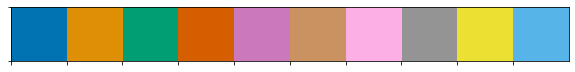

In [4]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [5]:
ensemble = Ensemble('../diabnet/models/model-6-soft-label-age-positives-1000-dropout0-bn-decay-flood-hyperopt-batch256-adamw-lc1-20200914')

../diabnet/models/model-6-soft-label-age-positives-1000-dropout0-bn-decay-flood-hyperopt-batch256-adamw-lc1-20200914


In [6]:
# feature names
feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [7]:
feat_names[-20:]

['snp_1_28265165',
 'snp_7_62322704',
 'snp_6_57432511',
 'snp_19_5147864',
 'snp_9_1667961',
 'snp_7_142786651',
 'snp_9_68692515',
 'snp_12_53198338',
 'snp_6_37571581',
 'snp_20_52032232',
 'snp_20_52032233',
 'snp_20_26104019',
 'snp_20_50189624',
 'snp_1_143276644',
 'snp_16_9536673',
 'snp_20_25734788',
 'AGE',
 'sex',
 'mo_t2d',
 'fa_t2d']

In [8]:
# predictor = load('../diabnet/models/model-sp-soft-label-positives-1000-decay2.pth')
# feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [9]:
e_train = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [10]:
e_test = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [11]:
def feat_importance(values, age, sex, samples_per_model=1):
    imp = values.calc_attr(age, sex, samples_per_model=samples_per_model)
    # testa se o SNP tem valores 1 ou 2. caso não tenha, sua importancia não pode ser calculada
    s = {k: [np.mean(imp[k]), np.median(imp[k])] for k in imp if len(imp[k]) > 0} 
    df = pd.DataFrame.from_dict(s, orient='index')
    df.rename(columns={0:f'{sex}{age}_mean', 1:f'{sex}{age}_median'}, inplace=True)
    # df.sort_values(by=0, ascending=False).head(50)
    return df
    

# Feature Importance

Qual a importância dos SNPs independentemente de outras características (sexo, diagnóstico dos pais, idade*).
*Para torna independente da idade fixamos a idade em 50.

In [12]:
age = 50
sex = 'X' # 'X' significa qualquer sexo

Não há um consenso se a análise de importância das características (feature importance) deve ser feita com os dados de teste ou treinamento. Nós testamos os dois...

In [ ]:
# feat_imp_train = feat_importance(e_train, 50, 'X', samples_per_model=1)

In [ ]:
feat_imp_test = feat_importance(e_test, 50, 'X', samples_per_model=1)

No entanto, no conjunto de teste 44 dos 1000 SNPs não possuem o gene base do alelo recessivo (valores 1 ou 2) e consequentemente, não conseguimos atribuir um valor de importância. E como notamos pelo boxplot abaixo, boa parte deles podem ser importantes.

In [ ]:
excluded = feat_imp_train[feat_imp_train.index.isin(feat_imp_test.index) == False]
print(f"{excluded.count()[0]} SNPs não tem valores no conjunto de teste")
sns.boxplot(y="X50_mean", data=excluded)

In [ ]:
tmp = feat_imp_train.join(feat_imp_test, how='inner', lsuffix='_train', rsuffix='_test')
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp = tmp.sort_values(by="X50_mean_train")
tmp # apenas 956 pq 44 dos SNPs não tem valores 1 ou 2 no conjunto de teste 

Comparando a média e a mediana da importância calculada para os conjuntos de treinamento e teste podemos ver que há uma correlação significativa (como esperado). Logo, optaremos por realizar as análises subsequentes apenas com a importância calculada no conjunto de treinamento.

In [ ]:
plt.figure(figsize=(12,6));
plt.subplot(121);
# plt.scatter(tmp.X50_mean_train.values, tmp.X50_mean_test.values);
sns.scatterplot(x="X50_mean_train", y="X50_mean_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.subplot(122);
# plt.scatter(tmp.X50_median_train.values, tmp.X50_median_test.values);
sns.scatterplot(x="X50_median_train", y="X50_median_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.figure(figsize=(12,4));
tmp.boxplot();

In [ ]:
sns.boxplot(y="X50_mean", data=feat_imp_train)

In [ ]:
feat_imp_train.describe()

In [ ]:
feat_imp_train["chr"] = [int(s.split('_')[1]) for s in feat_imp_train.index]
feat_imp_train["pos"] = [float(s.split('_')[2]) for s in feat_imp_train.index]
feat_imp_train

O gráfico da atribuição dos SNPs separado por cromossomo (abaixo) mostra que os chr 1 e 3 

In [ ]:
fig = plt.figure(figsize=(12,8))
plt.subplot(211)
sns.stripplot(x="chr", y="X50_mean", data=feat_imp_train, jitter=0.15)
plt.subplot(212)
sns.violinplot(x="chr", y="X50_mean", data=feat_imp_train, whis=np.inf)

In [ ]:
fig = plt.figure(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.25)
for i in range(22):
    ax1=plt.subplot(8, 3, i+1)
    plt.title(f"chr: {i+1}")
    sns.scatterplot(x='pos', y="X50_mean", data=feat_imp_train[feat_imp_train["chr"]==i+1], hue="X50_mean", hue_norm=(-0.3,0.3), palette="RdBu_r", edgecolor="k")
    ax1.get_legend().remove()
    plt.ylim(-0.5,0.5)
    plt.ylabel("")
    plt.xlabel("")


In [ ]:
selection = feat_imp_train[abs(feat_imp_train['X50_mean'])> 0.05]

In [ ]:
selection.sort_values(by='X50_mean').to_csv("feature_importance.csv")

In [ ]:
selection.sort_values(by='X50_mean', ascending=False).head(100)

In [ ]:
fig = plt.figure(figsize=(12,8))
plt.subplot(211)
# sns.stripplot(x="chr", y="X50_mean", data=selection, jitter=0.15)
sns.swarmplot(x="chr", y="X50_mean", data=selection)
plt.subplot(212)
# sns.barplot(x="chr", y="X50_mean", data=selection)
sns.countplot(x="chr", data=selection)

## Análise por sexo

In [ ]:
# feature importance - M x F
# age: 50, set: test

In [ ]:
feat_imp_M50 = feat_importance(e_train, 50, 'M', samples_per_model=1)
feat_imp_F50 = feat_importance(e_train, 50, 'F', samples_per_model=1)

In [ ]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp

In [ ]:
tmp.sort_values(by="M50_mean").to_csv("feature_importance_sex.csv")

In [ ]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_mean", y="F50_mean", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

In [ ]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_median", y="F50_median", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

In [ ]:
tmp.sort_values(by="F50_mean").tail(20)

In [ ]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.05]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

In [ ]:
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'])

In [ ]:
# feature importance - lifelong variability

In [ ]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')

In [ ]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'median' in i])

In [ ]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.04]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

In [ ]:
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'])

In [ ]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')
    

In [ ]:
[i for i in feat_imp_by_age.columns if 'mean' in i]

In [ ]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'mean' in i])

In [ ]:
feat_imp_by_age[['X90_mean']].boxplot()

In [ ]:
feat_imp_M50.sort_values(by=0, ascending=False).head(50)

In [ ]:
imp = e_test.calc_attr(20, 'X', samples_per_model=1)

In [ ]:
s

In [ ]:
dfnew.sort_values(by=0, ascending=True).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
df = pd.DataFrame.from_dict(s, orient='index')

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
import numpy as np
np.mean(df.values, axis=0)

In [ ]:
df_20_X = e_train.attr_snps_mean(attrs, mask).rename(columns={0: "age=20,sex=X"})

In [ ]:
df_20_X.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
attr, mask = e_train.calc_attr(20, 'X', samples=1)
df_20_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_train.calc_attr(20, 'M', samples=1)
df_20_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_train.calc_attr(20, 'F', samples=1)
df_20_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
df_decay2 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay2.head(20)

In [ ]:
df_decay1 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay1.head(20)

In [ ]:
df_train[df_train.index=='snp_4_172986805']

In [ ]:
attr, mask = e_train.calc_attr(50, 'X', samples=1)
df_50_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_train.calc_attr(50, 'M', samples=1)
df_50_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_train.calc_attr(50, 'F', samples=1)
df_50_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_train = df_20_X.join([df_20_F,df_20_M,df_50_X,df_50_F,df_50_M])

In [ ]:
df_train.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_train.sort_values(by="age=50,sex=X", ascending=False).tail(50)

In [ ]:
plt.boxplot(df_20_X.values)

In [ ]:
attr, mask = e_test.calc_attr(20, 'X', samples=1)
df_20_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_test.calc_attr(20, 'M', samples=1)
df_20_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_test.calc_attr(20, 'F', samples=1)
df_20_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
attr, mask = e_test.calc_attr(50, 'X', samples=1)
df_50_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_test.calc_attr(50, 'M', samples=1)
df_50_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_test.calc_attr(50, 'F', samples=1)
df_50_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_test = df_20_X_test.join([df_20_F_test,df_20_M_test,df_50_X_test,df_50_F_test,df_50_M_test])

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).tail(50)

In [ ]:
df = df_train.join(df_test, lsuffix='_train', rsuffix='_test')

In [ ]:
sns.pairplot(df.sort_values(by="age=20,sex=X_train", ascending=False).head(20))
# plt.savefig('pairplot.svg')

In [ ]:
df.sort_values(by="age=20,sex=X_train", ascending=False).head(20)

In [ ]:
df_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).head(100)

In [ ]:
df_sel

In [ ]:
tmp = dict(Counter([s[:s.index('_',4)] for s in list(df_sel.index)]))
sns.barplot(x=list(tmp.keys()), y=list(tmp.values()))

In [ ]:
df_not_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).tail(500)

In [ ]:
Counter([s[:s.index('_',4)] for s in list(df_not_sel.index)])

In [ ]:
list(tmp.values())

In [ ]:
plt.subplot(141)
plt.title("Precision")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.subplot(142)
plt.title("Recall")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(143)
plt.title("F1-Score")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(144)
plt.title("Frequency")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
plt.xscale('log')
plt.yticks([])

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
plt.boxplot(feat_imp_M50['M50_mean'])

In [ ]:
df_test = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [ ]:
df_train = pd.read_csv("../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [ ]:
c1 = df_test.columns
c2 = df_train.columns
for i in range(1009):
    if c1[i] != c2[i]:
        print(f"{c1[i]} = {c2[i]}")
    

In [ ]:
a = np.arange(-10,10)

In [ ]:
a

In [ ]:
plt.scatter(x=1,y=a)